In [3]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [4]:
mnist_dataset, mnist_info = tfds.load(name='mnist',with_info=True,as_supervised=True)
mnist_train,mnist_test=mnist_dataset['train'],mnist_dataset['test']
num_validation_samples=0.1*mnist_info.splits['train'].num_examples
num_validation_samples=tf.cast(num_validation_samples,tf.int64)
num_test_samples=mnist_info.splits['test'].num_examples
num_test_samples=tf.cast(num_test_samples,tf.int64)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.EEPYVA_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.EEPYVA_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [5]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label
scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [6]:
BUFFER_SIZE = 10000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [7]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [9]:
input_size=784
output_size=10
hidden_layer_size=50
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(output_size,activation='softmax')
])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
NUM_EPOCHS = 30
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)
model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose =1)

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8861 - loss: 0.4139 - val_accuracy: 0.9378 - val_loss: 0.2204
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9461 - loss: 0.1843 - val_accuracy: 0.9497 - val_loss: 0.1692
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9591 - loss: 0.1387 - val_accuracy: 0.9640 - val_loss: 0.1275
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9666 - loss: 0.1150 - val_accuracy: 0.9687 - val_loss: 0.1081
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9716 - loss: 0.0965 - val_accuracy: 0.9697 - val_loss: 0.0993
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9749 - loss: 0.0839 - val_accuracy: 0.9747 - val_loss: 0.0919
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9778 - loss: 0.0734 - val_accuracy: 0.9767 - val_loss: 0.0794
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9798 - loss: 0.0654 - val_accuracy: 

In [11]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step - accuracy: 0.9716 - loss: 0.1071
Test loss: 0.11. Test accuracy: 97.16%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


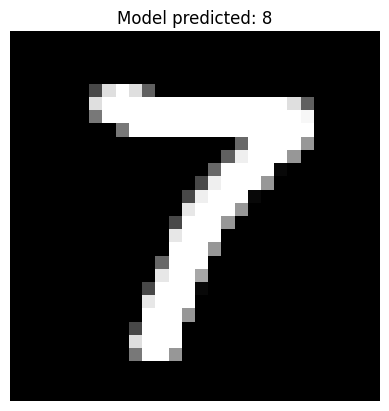

In [19]:
import cv2
image_path = 'my_digit_image (2).png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and if the file exists.")
else:
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    img_processed = img_resized
    img_normalized = img_processed / 255.0
    img_for_prediction = np.reshape(img_normalized, (1, 28, 28, 1))

    prediction = model.predict(img_for_prediction)
    predicted_digit = np.argmax(prediction)


    plt.imshow(img_processed, cmap='gray')
    plt.title(f"Model predicted: {predicted_digit}")
    plt.axis('off')
    plt.show()
